# 08 — Per-Series Win Analysis by Configuration and Feature

For each of the 6 features and each model configuration, we count the number of
(unique_id, window) pairs for which that configuration achieves the **lowest
RelNaive** (i.e. is the best model for that specific series and window).

Configurations included:
- **Non-linear models** — bucket-finetuned (oracle assignment: each series uses its bucket model)
- **Linear models** — global baseline (no finetuning)
- **Statistical models** — global baseline (no finetuning)

Each configuration is a (model × decomposition) pair. Ties are shared equally.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
DATA = Path("data")

master = pd.read_parquet(DATA / "master_metrics.parquet")

NL_MODELS   = ["AutoXGBoost","AutoLSTM","AutoRandomForest","AutoNHITS","AutoTFT","AutoPatchTST"]
LIN_MODELS  = ["AutoRidge","AutoLinearRegression","AutoNLinear"]
STAT_MODELS = ["AutoARIMA","AutoETS","AutoSARIMA"]
ALL_MODELS  = NL_MODELS + LIN_MODELS + STAT_MODELS

DECOMP_LABELS = {"without_stl":"Direct","stl_seasonal_naive":"STL-SN",
                 "stl_model_all_components":"STL-AC"}
FEAT_SHORT = {
    "feature_non_normality":             "Non-normality",
    "feature_nonlinearity":              "Nonlinearity",
    "feature_spectral_entropy":          "Spectral entropy",
    "feature_evolving_seasonality":      "Evolv. seasonality",
    "feature_structural_break_strength": "Structural break",
    "feature_arch_stat":                 "ARCH/volatility",
}
FEATURES = list(FEAT_SHORT.keys())

# --- Build unified performance table (same as NB07) ---
nl = master[
    master["model_name"].isin(NL_MODELS) &
    master["finetuning_mode"].str.startswith("finetune_bucket_")
].copy()
nl["config"] = "FT"

other = master[
    master["model_name"].isin(LIN_MODELS + STAT_MODELS) &
    (master["finetuning_mode"] == "no_finetune")
].copy()
other["config"] = "GL"

perf = pd.concat([nl, other], ignore_index=True)
perf["decomp_label"] = perf["decomposition_method"].map(DECOMP_LABELS)
perf["cfg_label"] = perf["model_name"] + " / " + perf["decomp_label"] + " (" + perf["config"] + ")"

print(f"Perf table: {len(perf):,} rows, {perf['cfg_label'].nunique()} configurations")
print(f"Series per feature: {perf[perf['feature_name']==FEATURES[0]]['unique_id'].nunique()} unique_ids")


Perf table: 1,932,984 rows, 36 configurations
Series per feature: 3000 unique_ids


## Per-Feature Win Tables

For each feature: pivot to wide format (series × config), find winner per row, aggregate.

In [2]:
def win_table(feat_data):
    """
    Given perf data for ONE feature, return a DataFrame with win counts per config.
    A config wins a (unique_id, window) if it has the minimum rel_naive_clipped.
    Ties split equally.
    """
    # Deduplicate on (unique_id, window, cfg_label) -- take mean if duplicates
    df = (feat_data
          .groupby(["unique_id","window","cfg_label"])["rel_naive_clipped"]
          .mean()
          .reset_index())

    # Pivot: rows = (unique_id, window), cols = cfg_label
    wide = df.pivot_table(index=["unique_id","window"], columns="cfg_label",
                          values="rel_naive_clipped")

    total = len(wide)
    # Row-wise minimum
    row_min = wide.min(axis=1)
    # For each row, which cols equal the minimum? (handles ties)
    is_winner = wide.eq(row_min, axis=0)
    # Win share: each tied winner gets 1/n_tied
    n_tied = is_winner.sum(axis=1)
    win_share = is_winner.div(n_tied, axis=0)
    win_counts = win_share.sum(axis=0)

    result = pd.DataFrame({
        "configuration": win_counts.index,
        "wins":          win_counts.values,
        "pct":           win_counts.values / total * 100,
    }).sort_values("wins", ascending=False).reset_index(drop=True)
    result.insert(0, "rank", result.index + 1)
    result["total_series"] = total
    return result

all_tables = {}
for feat in FEATURES:
    feat_data = perf[perf["feature_name"] == feat]
    t = win_table(feat_data)
    all_tables[feat] = t
    print(f"{FEAT_SHORT[feat]:<22}: {len(t)} configs, {int(t['total_series'].iloc[0]):,} (series x windows)")


Non-normality         : 36 configs, 8,949 (series x windows)


Nonlinearity          : 36 configs, 8,949 (series x windows)


Spectral entropy      : 36 configs, 8,949 (series x windows)


Evolv. seasonality    : 36 configs, 8,949 (series x windows)


Structural break      : 36 configs, 8,949 (series x windows)


ARCH/volatility       : 36 configs, 8,949 (series x windows)


In [3]:
# Display each feature's table (top 20 configs by win count)
for feat in FEATURES:
    t = all_tables[feat]
    total = int(t["total_series"].iloc[0])
    print(f"\n{'='*70}")
    print(f"Feature: {FEAT_SHORT[feat]}  (total: {total:,} series-window pairs)")
    print(f"{'='*70}")
    top = t[t["wins"] > 0].head(25).copy()
    top["wins"] = top["wins"].round(1)
    top["pct"]  = top["pct"].round(2)
    print(top[["rank","configuration","wins","pct"]].to_string(index=False))
    # Save
    t.to_csv(DATA / f"table_wins_{feat}.csv", index=False)



Feature: Non-normality  (total: 8,949 series-window pairs)
 rank                      configuration  wins  pct
    1              AutoETS / Direct (GL) 893.0 9.98
    2            AutoARIMA / Direct (GL) 546.3 6.10
    3           AutoSARIMA / Direct (GL) 546.3 6.10
    4     AutoRandomForest / Direct (FT) 529.0 5.91
    5              AutoTFT / Direct (FT) 488.0 5.45
    6             AutoLSTM / Direct (FT) 448.0 5.01
    7            AutoNHITS / Direct (FT) 411.0 4.59
    8     AutoRandomForest / STL-AC (FT) 395.0 4.41
    9          AutoXGBoost / Direct (FT) 386.5 4.32
   10              AutoTFT / STL-AC (FT) 380.0 4.25
   11     AutoRandomForest / STL-SN (FT) 334.0 3.73
   12             AutoLSTM / STL-AC (FT) 326.0 3.64
   13         AutoPatchTST / Direct (FT) 309.0 3.45
   14          AutoXGBoost / STL-AC (FT) 265.0 2.96
   15         AutoPatchTST / STL-AC (FT) 261.0 2.92
   16 AutoLinearRegression / Direct (GL) 245.7 2.75
   17              AutoETS / STL-AC (GL) 235.0 2.63
   1

## Summary Heatmap — Top Configurations Across Features

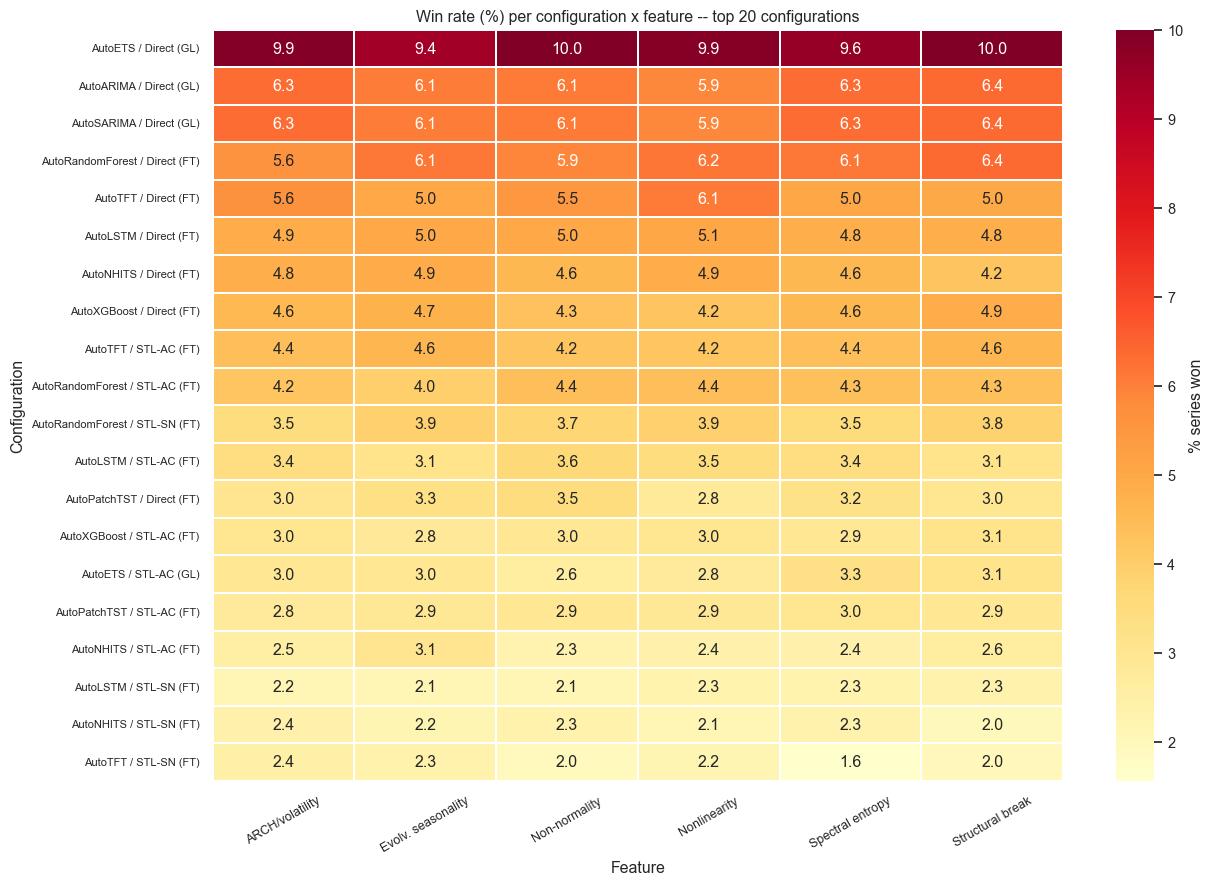

In [4]:
# Identify the top-N configs across all features (by total wins summed)
all_cfgs = pd.concat(
    [t[["configuration","wins"]].assign(feature=feat) for feat, t in all_tables.items()],
    ignore_index=True
)
total_wins = all_cfgs.groupby("configuration")["wins"].sum().sort_values(ascending=False)
top_cfgs = total_wins.head(20).index.tolist()

# Build a (feature x config) win% pivot
pivot_rows = []
for feat in FEATURES:
    t = all_tables[feat]
    total = t["total_series"].iloc[0]
    for _, r in t.iterrows():
        pivot_rows.append({
            "feature": FEAT_SHORT[feat],
            "configuration": r["configuration"],
            "pct": r["pct"],
        })
pivot_df = pd.DataFrame(pivot_rows)
heatmap_data = pivot_df[pivot_df["configuration"].isin(top_cfgs)].pivot(
    index="configuration", columns="feature", values="pct"
).fillna(0)

# Order rows by total wins
heatmap_data = heatmap_data.loc[
    [c for c in top_cfgs if c in heatmap_data.index]
]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(heatmap_data, ax=ax, cmap="YlOrRd",
            annot=True, fmt=".1f", linewidths=0.3,
            cbar_kws={"label": "% series won"})
ax.set_title("Win rate (%) per configuration x feature -- top 20 configurations")
ax.set_xlabel("Feature")
ax.set_ylabel("Configuration")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.savefig(DATA / "fig_win_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Stacked Bar Charts — Win Share by Model Group per Feature

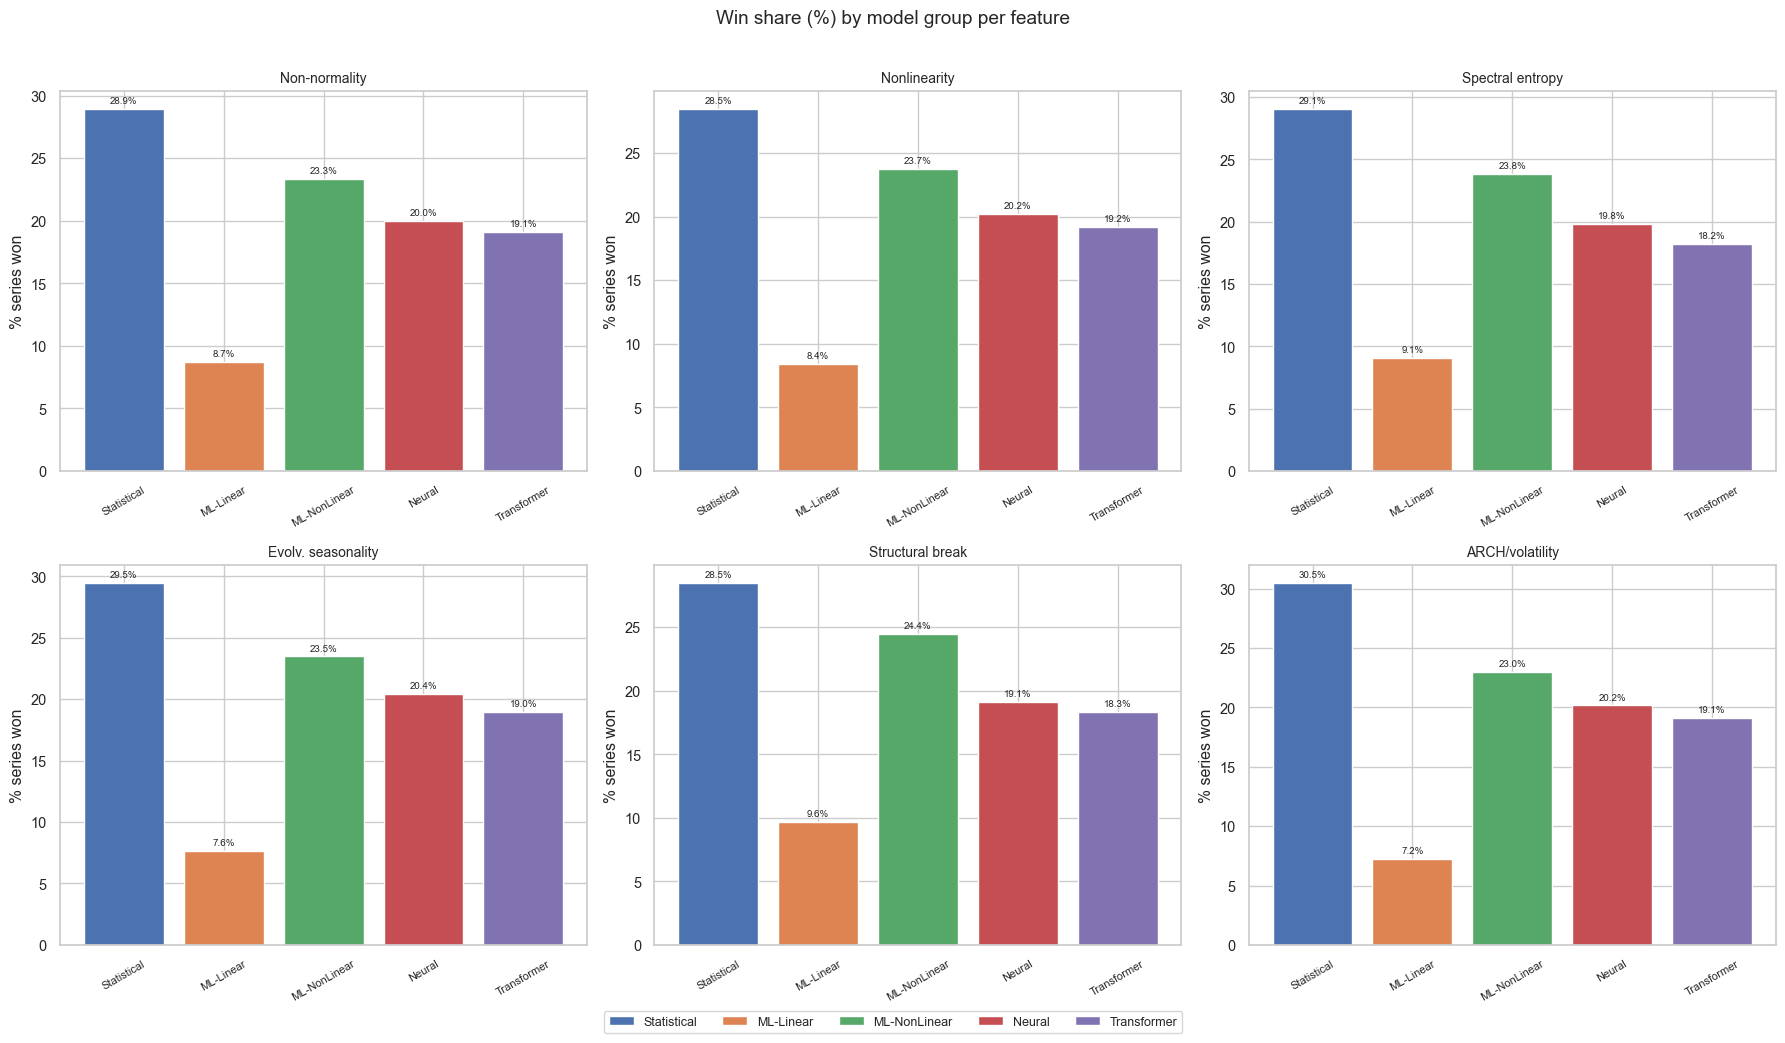

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes_flat = axes.flatten()

group_colors = {
    "Statistical": "#4C72B0",
    "ML-Linear":   "#DD8452",
    "ML-NonLinear":"#55A868",
    "Neural":      "#C44E52",
    "Transformer": "#8172B2",
}

def model_group(cfg):
    if any(m in cfg for m in ["AutoARIMA","AutoETS","AutoSARIMA"]): return "Statistical"
    if any(m in cfg for m in ["AutoRidge","AutoLinearRegression","AutoNLinear"]): return "ML-Linear"
    if any(m in cfg for m in ["AutoXGBoost","AutoRandomForest"]): return "ML-NonLinear"
    if any(m in cfg for m in ["AutoLSTM","AutoNHITS","AutoNLinear"]): return "Neural"
    if any(m in cfg for m in ["AutoTFT","AutoPatchTST"]): return "Transformer"
    return "Other"

for ax, feat in zip(axes_flat, FEATURES):
    t = all_tables[feat]
    t = t[t["wins"] > 0].copy()
    t["group"] = t["configuration"].apply(model_group)
    group_pct = t.groupby("group")["pct"].sum().reindex(list(group_colors.keys()), fill_value=0)

    bars = ax.bar(group_pct.index, group_pct.values,
                  color=[group_colors[g] for g in group_pct.index],
                  edgecolor="white")
    ax.set_title(FEAT_SHORT[feat], fontsize=10)
    ax.set_ylabel("% series won")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    for bar, val in zip(bars, group_pct.values):
        if val > 1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=7)

from matplotlib.patches import Patch
legend_el = [Patch(facecolor=v, label=k) for k, v in group_colors.items()]
fig.legend(handles=legend_el, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Win share (%) by model group per feature", y=1.01)
fig.tight_layout()
plt.savefig(DATA / "fig_win_by_group.png", dpi=150, bbox_inches="tight")
plt.show()


## Aggregate: Total Wins Across All Features

In [6]:
agg = (all_cfgs.groupby("configuration")["wins"].sum()
       .sort_values(ascending=False)
       .reset_index())
agg.insert(0, "rank", agg.index + 1)

total_all = sum(all_tables[f]["total_series"].iloc[0] * all_tables[f]["pct"].sum() / 100
                for f in FEATURES)
total_pairs = sum(all_tables[f]["total_series"].iloc[0] for f in FEATURES)
agg["pct_of_total"] = (agg["wins"] / total_pairs * 100).round(2)

print(f"Total (series x window x feature) pairs: {total_pairs:,.0f}")
print()
print(f"{'Rank':<5} {'Configuration':<45} {'Total wins':>11} {'% of total':>10}")
print("-" * 75)
for _, r in agg[agg["wins"] > 0].iterrows():
    print(f"{r['rank']:<5} {r['configuration']:<45} {r['wins']:>11.1f} {r['pct_of_total']:>9.2f}%")

agg.to_csv(DATA / "table_wins_aggregate.csv", index=False)


Total (series x window x feature) pairs: 53,694

Rank  Configuration                                  Total wins % of total
---------------------------------------------------------------------------
1     AutoETS / Direct (GL)                              5258.8      9.79%
2     AutoARIMA / Direct (GL)                            3317.7      6.18%
3     AutoSARIMA / Direct (GL)                           3317.7      6.18%
4     AutoRandomForest / Direct (FT)                     3248.0      6.05%
5     AutoTFT / Direct (FT)                              2880.0      5.36%
6     AutoLSTM / Direct (FT)                             2640.0      4.92%
7     AutoNHITS / Direct (FT)                            2508.0      4.67%
8     AutoXGBoost / Direct (FT)                          2445.0      4.55%
9     AutoTFT / STL-AC (FT)                              2368.0      4.41%
10    AutoRandomForest / STL-AC (FT)                     2294.0      4.27%
11    AutoRandomForest / STL-SN (FT)              

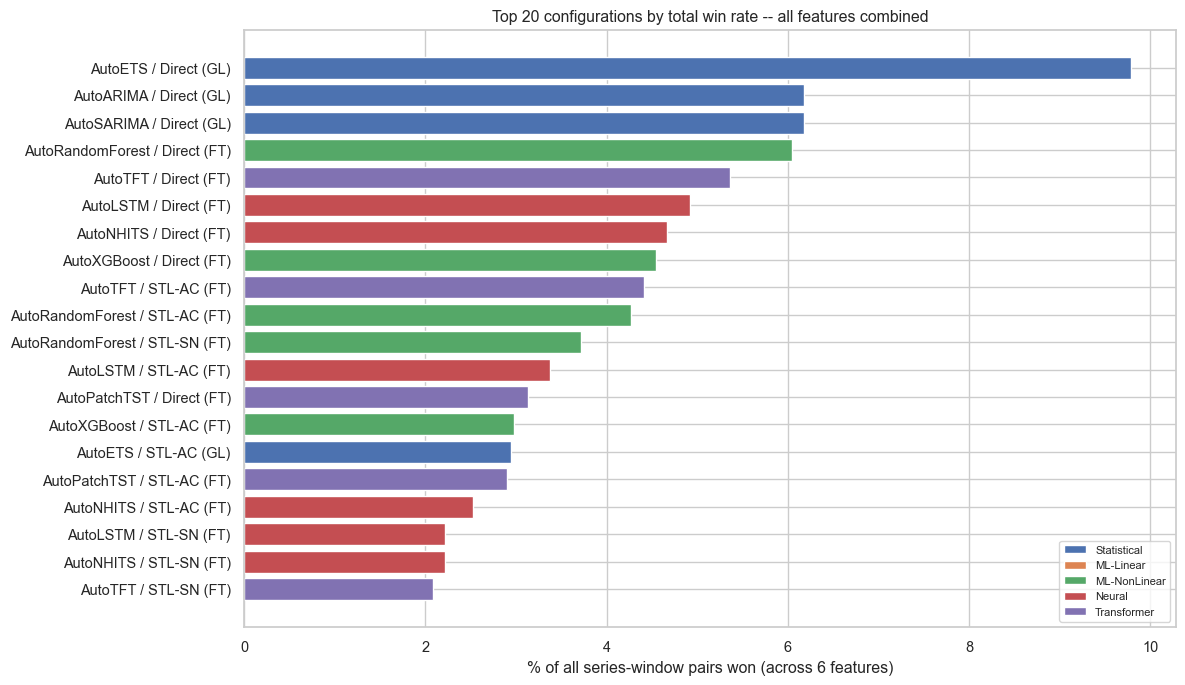

In [7]:
# Top 20 bar chart
top20 = agg[agg["wins"] > 0].head(20).copy()
top20["group"] = top20["configuration"].apply(model_group)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [group_colors.get(g, "gray") for g in top20["group"]]
ax.barh(top20["configuration"][::-1], top20["pct_of_total"][::-1],
        color=colors[::-1], edgecolor="white")
ax.set_xlabel("% of all series-window pairs won (across 6 features)")
ax.set_title("Top 20 configurations by total win rate -- all features combined")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in group_colors.items()],
          fontsize=8, loc="lower right")
fig.tight_layout()
plt.savefig(DATA / "fig_win_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()
